In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit import QuantumCircuit
from collections import Counter

In [3]:
from vqe_optimization_goldstein import VQECOpt_goldstein 

In [4]:
from commutator_funcs import *
from dcd_ansatz import *

## VQEC workflow

In [5]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [6]:
def classify_amino_acids(sequence):
    hydrophobic = set('GAVLIPFMW')
    return ''.join('H' if amino in hydrophobic else 'P' for amino in sequence)

In [7]:
print(classify_amino_acids("LFLF"))

HHHH


In [8]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(classify_amino_acids(main_seq_4), 'hp_matrix')
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0. -1. -1. -1.]
 [ 0.  0. -1. -1.]
 [ 0.  0.  0. -1.]
 [ 0.  0.  0.  0.]]
Number of qubits: 9
Number of terms: 107


In [9]:

def analyze_pauli_terms(pauli_op: SparsePauliOp):
    # Extract labels from the Pauli operator
    labels = pauli_op.paulis.to_labels()
    
    # Initialize a Counter to store occurrences of each Pauli term type
    term_types = Counter()
    
    # Iterate over each label and process
    # Skip the sorting to keep 'XZ' and 'ZX' distinct
    for label in labels:
        # Remove identity matrices, keep the order of non-identity Pauli matrices
        normalized_label = label.replace('I', '')
        if normalized_label == '':
            normalized_label = 'I'  # Include identity as a term if all are 'I'
        term_types[normalized_label] += 1
    
    # Return a dictionary of term types with their counts
    return dict(term_types)


In [10]:
dcd_hamiltonian = calculate_commutator(qubit_op, True, 1)
analyze_pauli_terms(dcd_hamiltonian)

{'Y': 8, 'YZ': 20, 'ZY': 20}

In [11]:

def select_terms(dcd_hamiltonian, term_analysis, num_qubits):
    # Extract labels and coefficients
    labels = dcd_hamiltonian.paulis.to_labels()
    coeffs = dcd_hamiltonian.coeffs
    
    # Determine the weight-2 term with the lowest count
    lowest_count = float('inf')
    lowest_term_type = None
    for term, count in term_analysis.items():
        if len(term) == 2 and count < lowest_count:
            lowest_count = count
            lowest_term_type = term

    # Initialize a list to collect the selected terms with their coefficients
    selected_terms = []
    
    # Filter the terms based on the analysis
    for label, coeff in zip(labels, coeffs):
        normalized_label = ''.join(sorted(label.replace('I', '')))
        
        # Select weight-1 terms where the count matches the number of qubits
        if normalized_label in term_analysis and len(normalized_label) == 1 and term_analysis[normalized_label] == num_qubits:
            selected_terms.append((label, coeff))
        
        # Select weight-2 terms of the type with the lowest count
        elif normalized_label == lowest_term_type:
            selected_terms.append((label, coeff))

    # Return a new SparsePauliOp with the selected terms
    return SparsePauliOp.from_list(selected_terms)


In [12]:
optimal_dcd_selection = select_terms(dcd_hamiltonian, analyze_pauli_terms(dcd_hamiltonian), qubit_op.num_qubits)

In [13]:
cd_ansatz = dig_count_ansatz(optimal_dcd_selection)

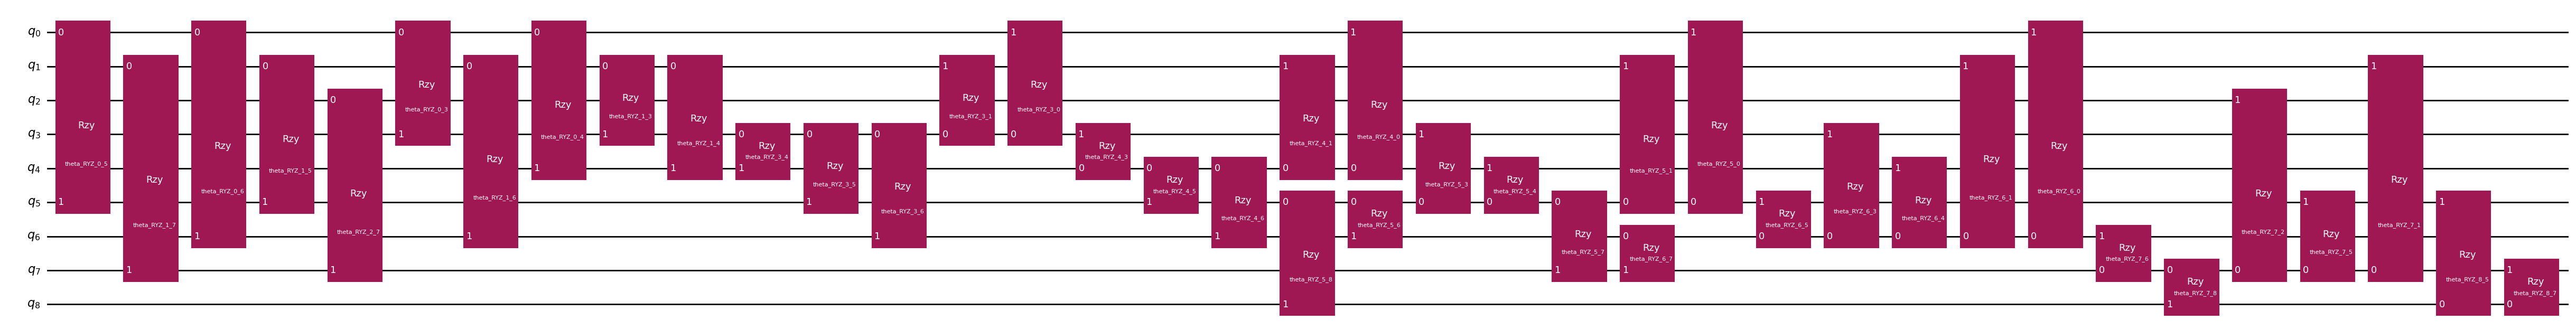

In [14]:
cd_ansatz.draw('mpl', fold=-1)

In [15]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [16]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
gradient_lincomb = LinCombEstimatorGradient(estimator=estimator)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_76824\81681451.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


Running optimization 1/100 with omega=0.1, theta=0.7


 46%|████▌     | 91/200 [01:32<01:50,  1.02s/it]

Goldstein test failed at iteration 90. Reducing step size.


 56%|█████▌    | 111/200 [01:52<01:24,  1.05it/s]

Goldstein test failed at iteration 110. Reducing step size.


...

 19%|█▉        | 38/200 [00:39<02:32,  1.06it/s]

Goldstein test failed at iteration 37. Reducing step size.


100%|██████████| 200/200 [03:18<00:00,  1.01it/s]


Running optimization 100/100 with omega=0.1, theta=0.7


100%|██████████| 200/200 [03:12<00:00,  1.04it/s]


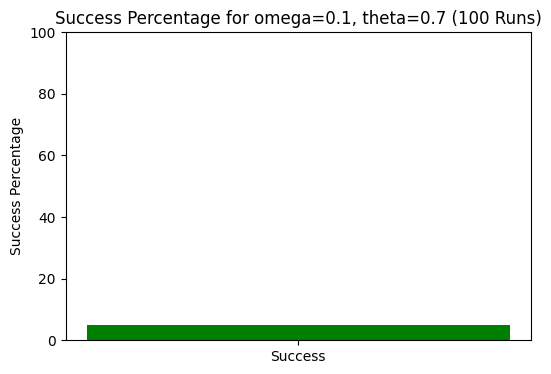

Success percentage for omega=0.1, theta=0.7 over 100 runs: 5.00%


In [17]:
# Set the omega and theta values for the most successful pair
omega = 0.1
theta = 0.7
target_bitstring = "111111110"
num_runs = 100
success_count = 0

# Run the optimization 100 times
for run in range(num_runs):
    print(f"Running optimization {run + 1}/{num_runs} with omega={omega}, theta={theta}")
    
    # Initialize the VQECOpt_goldstein with the best omega and theta values
    vqec_lincomb = VQECOpt_goldstein(
        primal_perturb_step=0.05,
        dual_perturb_step=0.05,
        omega=omega,
        theta=theta,
        qubit_op=qubit_op,
        constr_ops=olap_constr_ops,
        ansatz=cd_ansatz,
        estimator=estimator,
        gradient=gradient_lincomb,
        max_iter=200
    )
    
    # Run the optimization
    vqec_lincomb_result = vqec_lincomb.optimize_primal_dual()

    # Get the optimized ansatz and sample from it
    full_circ = vqec_lincomb_result.ansatz.copy()
    full_circ.measure_all()
    
    # Initialize the sampler
    sampler = Sampler(options={"shots": 10000})
    sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_lincomb_result.optimal_primal_vars).result()
    
    # Get the quasi-probabilities and sort them
    quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
    sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
    
    # Check top 5 bitstrings
    found = False  # Flag to track if the target bitstring is found
    for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
        if i >= 5:  # Only check the top 5
            break
        
        # Check if the target bitstring is among the top 5
        if sample == target_bitstring:
            found = True
            break

    # If the target bitstring is found, increment the success count
    if found:
        success_count += 1

# Calculate the success percentage
success_percentage = (success_count / num_runs) * 100

# Plot the success percentage
plt.figure(figsize=(6, 4))
plt.bar(['Success'], [success_percentage], color='green')
plt.title(f'Success Percentage for omega={omega}, theta={theta} (100 Runs)')
plt.ylabel('Success Percentage')
plt.ylim(0, 100)
plt.show()

# Print the success percentage
print(f"Success percentage for omega={omega}, theta={theta} over {num_runs} runs: {success_percentage:.2f}%")


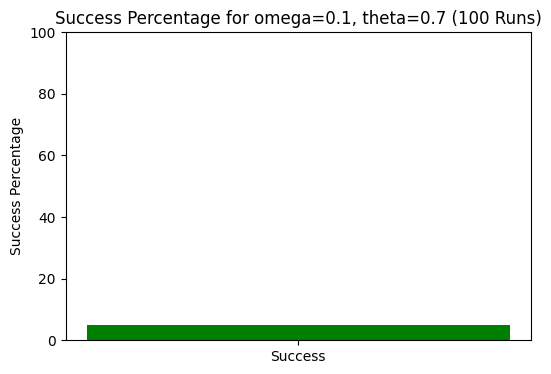

Success percentage for omega=0.1, theta=0.7 over 100 runs: 5.00%


In [20]:
# Calculate the success percentage
success_percentage = (success_count / num_runs) * 100

# Plot the success percentage
plt.figure(figsize=(6, 4))
plt.bar(['Success'], [success_percentage], color='green')
plt.title(f'Success Percentage for omega={omega}, theta={theta} (100 Runs)')
plt.ylabel('Success Percentage')
plt.ylim(0, 100)
plt.show()

# Print the success percentage
print(f"Success percentage for omega={omega}, theta={theta} over {num_runs} runs: {success_percentage:.2f}%")

In [21]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-3.0
-1.0
